# The Bodega Problem: Revenue Leakage from Hidden Inventory.

## 1. Executive Summary.

This project addresses a hidden source of revenue leakage in retail operations, where products remain in backroom inventory due to limited shelf space, making them effectively unavailable for purchase.

This initiative is based on a real operational challenge observed during my experience at FEMSA.

A predictive model was developed to quantify the financial impact of unexhibited inventory by estimating the relationship between product visibility and sales performance under realistic retail conditions.

At the store level, the analysis shows that approximately **12% of the assortment** is affected by hidden inventory, with an average estimated impact of **4,531 MXN per store** (≈ **257 USD**). The primary driver of lost sales is **product price**, with higher-value items experiencing disproportionately larger revenue losses when not displayed.

Following initial validation in a single store, the approach was expanded across **one Region (multi-store)**, confirming the consistency and scalability of the findings. The implementation of an **Inventory Visibility KPI** enabled continuous monitoring of merchandising execution and early detection of revenue leakage.

These results demonstrate that targeted **SKU-level visibility management** can help recover revenue by prioritizing high-impact products for display and improving in-store execution.

When extrapolated across a network of 13,000 stores (in 2013; Oxxo currently operates more than 23,000 stores in Mexico), this translates into a **simulated recoverable revenue of approximately** **58.9 million MXN*** (≈ **3.34 million USD**), demonstrating how small visibility gaps at the store level can compound into meaningful financial impact at scale.

<p style="font-size:11px; line-height:1.3; color:#666;">
<em>
*Note: Network extrapolation assumes a minimum level of hidden inventory presence per store, based on observed assortment-level impact. It represents a directional estimate to demonstrate scale, not an exact realized total.
</em>
</p>

## 2. Business Context.

In large-scale retail operations, system inventory does not always reflect real customer availability.  
At FEMSA’s convenience retail division, a recurring operational problem involved products that **existed in store backrooms but had zero presence on shelves**.

These items remained stored in backrooms instead of being exhibited on the sales floor.

From a systems perspective, the inventory existed, but commercially, the product was unavailable to the customer at the point of purchase.

This created a critical blind spot: products appeared to be in stock but were not positioned to generate sales.

The issue was especially common in two types of products:

- **High-priced items** such as whiskey, tequila, selected wines, and some cell phones, which were often withheld from shelves due to theft risk.
- **Low-rotation items** such as certain toys and baby products, which store personnel sometimes removed to free shelf space for faster-selling categories.

In practice, these decisions responded to real store-level pressures: shrink prevention, limited shelf capacity, and the need to prioritize products with stronger turnover. However, they also created hidden revenue loss by reducing the visibility and sell-through potential of products that were technically available in inventory.

The issue was widely recognized across Marketing, Operations, and store personnel, who regularly discussed the operational trade-offs involved in shelf allocation and theft prevention.

However, these conversations were largely based on experience and intuition rather than quantitative analysis.

The organization lacked a structured way to **measure the financial impact of unexhibited inventory** or determine which products represented the greatest revenue risk when kept off-shelf.

As part of the Operational Processes team, I led an initiative to investigate this issue and estimate the **lost sales associated with unexhibited inventory**.

This project recreates that analytical challenge using simulated operational data and predictive modeling to estimate lost sales at the SKU level and support better shelf allocation, inventory visibility, and category decision-making.

## 3. Analytical Objective.

The objective of this analysis was to quantify the commercial impact of **unexhibited inventory**, products that were present in store inventory records but absent from the sales floor.

Although the issue was widely recognized by Marketing, Operations, and store personnel, discussions around shelf allocation and theft prevention were typically guided by operational judgment rather than measurable financial evidence.

The initiative sought to introduce analytical rigor into this discussion by answering three practical questions:

- **How much revenue is lost when products remain off-shelf despite being available in inventory?**
- **Which product characteristics are most associated with this revenue leakage?**
- **How can this problem be monitored through measurable indicators to support operational improvement?**

To address these questions, a predictive model was developed to estimate **lost sales at the SKU level** using operational variables such as inventory levels, pricing, and demand signals.

Beyond modeling, the goal was to translate the results into **clear financial metrics** that could be tracked over time, allowing the organization to incorporate unexhibited inventory **into a continuous improvement cycle** with defined **monitoring indicators and corrective actions.**

## 4. Analytical Approach.

This analysis evaluates the **revenue impact of unexhibited inventory**, combining exploratory data analysis with predictive modeling.

**a) Operational Data Environment.**

Because operational data from FEMSA is confidential, a **synthetic dataset** is generated directly within the notebook. The dataset reproduces common dynamics observed in convenience retail operations and simulates SKU-level variables including:

- Product pricing.
- Demand velocity.
- Inventory levels.
- Shelf display quantity.
- Units stored in backroom areas rather than exhibited.

**b) Category Behavior Simulation.**

The dataset generator incorporates **category-specific retail behavior** observed in real store operations:

- **High-value items.** Spirits, wine, cell phones, accessories, have a higher probability of remaining unexhibited due to theft risk or controlled storage policies.
- **Seasonal or slower-rotation products.** Toys, specialty items, may temporarily remain in backroom areas when shelf space is prioritized for faster-moving merchandise.
- **High-frequency convenience staples.** Snacks, beverages, impulse products, typically maintain continuous shelf presence due to rapid turnover.
- **Moderate-velocity categories.** Such as personal hygiene, cleaning supplies, dairy, bread, and ready-to-eat meals generally remain displayed under normal operating conditions.

**c) Analytical Strategy.**

Within this simulated operational environment, the analysis applies **regression modeling** to estimate how product characteristics and inventory conditions influence the magnitude of potential **lost revenue when items remain unexhibited**.

The following subsections implement the analytical workflow used to quantify this effect.

### 4.1 Dataset Construction and Validation.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

In [2]:
# Synthetic dataset generator reflecting operational behavior

import numpy as np
import pandas as pd

np.random.seed(42)

n_products = 200

categories = [
    "Spirits","Wine","Beer","Cell Phones","Phone Accessories","Toys",
    "Seasonal Items","Gift Items","School Supplies","Baby Products",
    "Snacks","Candy","Chocolates","Gum","Chips","Cookies","Pastries",
    "Soda","Bottled Water","Juice","Energy Drinks","Sports Drinks",
    "Coffee / Ready-to-Drink Coffee","Dairy","Bread","Instant Meals",
    "Personal Hygiene","Toiletries","Cleaning Products","Paper Products",
    "Batteries"
]

data = []

for i in range(n_products):

    category = np.random.choice(categories)

    # Theft-risk categories
    if category == "Spirits":
        unit_price = np.random.uniform(25,80)
        daily_sales_rate = np.random.uniform(2,6)
        hidden_prob = 0.65

    elif category == "Wine":
        unit_price = np.random.uniform(15,60)
        daily_sales_rate = np.random.uniform(2,5)
        hidden_prob = 0.55

    elif category == "Cell Phones":
        unit_price = np.random.uniform(150,700)
        daily_sales_rate = np.random.uniform(0.2,1.5)
        hidden_prob = 0.75

    elif category == "Phone Accessories":
        unit_price = np.random.uniform(10,60)
        daily_sales_rate = np.random.uniform(1,4)
        hidden_prob = 0.45

    # Low rotation / seasonal
    elif category == "Toys":
        unit_price = np.random.uniform(10,50)
        daily_sales_rate = np.random.uniform(0.3,1.5)
        hidden_prob = 0.50

    elif category == "Seasonal Items":
        unit_price = np.random.uniform(5,40)
        daily_sales_rate = np.random.uniform(0.2,1.2)
        hidden_prob = 0.55

    elif category == "Gift Items":
        unit_price = np.random.uniform(5,50)
        daily_sales_rate = np.random.uniform(0.3,2)
        hidden_prob = 0.40

    elif category == "School Supplies":
        unit_price = np.random.uniform(3,20)
        daily_sales_rate = np.random.uniform(0.5,2)
        hidden_prob = 0.35

    # High rotation staples
    elif category in ["Snacks","Chips","Cookies","Pastries"]:
        unit_price = np.random.uniform(2,8)
        daily_sales_rate = np.random.uniform(20,60)
        hidden_prob = 0.03

    elif category in ["Candy","Chocolates","Gum"]:
        unit_price = np.random.uniform(1,6)
        daily_sales_rate = np.random.uniform(25,70)
        hidden_prob = 0.03

    elif category in ["Soda","Energy Drinks","Sports Drinks","Juice","Bottled Water"]:
        unit_price = np.random.uniform(1.5,5)
        daily_sales_rate = np.random.uniform(30,80)
        hidden_prob = 0.02

    # Food staples
    elif category in ["Dairy","Bread","Instant Meals"]:
        unit_price = np.random.uniform(3,15)
        daily_sales_rate = np.random.uniform(10,25)
        hidden_prob = 0.04

    # Household
    elif category in ["Personal Hygiene","Toiletries","Cleaning Products","Paper Products"]:
        unit_price = np.random.uniform(4,20)
        daily_sales_rate = np.random.uniform(4,12)
        hidden_prob = 0.05

    elif category == "Baby Products":
        unit_price = np.random.uniform(10,60)
        daily_sales_rate = np.random.uniform(4,12)
        hidden_prob = 0.05

    elif category == "Batteries":
        unit_price = np.random.uniform(5,25)
        daily_sales_rate = np.random.uniform(2,8)
        hidden_prob = 0.15

    else:
        unit_price = np.random.uniform(2,20)
        daily_sales_rate = np.random.uniform(5,20)
        hidden_prob = 0.05

    stock_quantity = np.random.randint(40,500)

    if np.random.rand() < hidden_prob:
        unexhibited_units = np.random.randint(5, int(stock_quantity * 0.6))
    else:
        unexhibited_units = 0

    shelf_quantity = stock_quantity - unexhibited_units

    gross_margin_pct = np.random.uniform(20,50)
    seasonality_factor = np.random.uniform(0.8,1.2)

    # Calibrated demand-loss capture to align with ~ $4k average loss among affected SKUs
    lost_demand_capture = np.random.uniform(0.35, 0.50)

    estimated_lost_sales = (
        unexhibited_units *
        unit_price *
        daily_sales_rate *
        seasonality_factor *
        lost_demand_capture
    )

    data.append([
        f"P{i:04}",
        f"Product_{i}",
        category,
        stock_quantity,
        shelf_quantity,
        unit_price,
        gross_margin_pct,
        daily_sales_rate,
        seasonality_factor,
        unexhibited_units,
        estimated_lost_sales
    ])

columns = [
    "product_id","product_name","category","stock_quantity","shelf_quantity",
    "unit_price","gross_margin_pct","daily_sales_rate","seasonality_factor",
    "unexhibited_units","estimated_lost_sales"
]

df = pd.DataFrame(data, columns=columns)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200, 11)


,product_id,product_name,category,stock_quantity,shelf_quantity,unit_price,gross_margin_pct,daily_sales_rate,seasonality_factor,unexhibited_units,estimated_lost_sales
0,P0000,Product_0,Seasonal Items,111,111,32.879005,24.680559,0.383435,0.862398,0,0.000000
1,P0001,Product_1,Dairy,170,164,7.004503,41.659963,12.143002,1.175421,6,210.020224
2,P0002,Product_2,Toiletries,61,32,6.934472,28.736874,6.433938,1.044741,29,501.397317
3,P0003,Product_3,Toiletries,485,485,19.580088,25.990213,5.862171,1.005694,0,0.000000
4,P0004,Product_4,Beer,368,368,17.478927,48.466566,15.204613,1.186253,0,0.000000


### 4.2 Data Inspection and Preparation.

Before modeling, the dataset is inspected to confirm structural integrity and ensure that all variables generated by the simulation process behave as expected.

This stage verifies:

- Column names and dataset structure.  
- Variable data types.  
- The presence of missing values in critical fields.  

Categorical variables must also be prepared for use in regression models. The `category` column is encoded into a numerical representation so that it can be included as a predictor in the OLS regression framework.

These preprocessing steps ensure the dataset is clean, consistent, and ready for exploratory analysis and modeling.

In [3]:
# Check dataset structure
df.info()

# Check missing values
df.isnull().sum()

# Encode category variable
df["category_encoded"] = df["category"].astype("category").cat.codes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_id            200 non-null    object 
 1   product_name          200 non-null    object 
 2   category              200 non-null    object 
 3   stock_quantity        200 non-null    int64  
 4   shelf_quantity        200 non-null    int64  
 5   unit_price            200 non-null    float64
 6   gross_margin_pct      200 non-null    float64
 7   daily_sales_rate      200 non-null    float64
 8   seasonality_factor    200 non-null    float64
 9   unexhibited_units     200 non-null    int64  
 10  estimated_lost_sales  200 non-null    float64
dtypes: float64(5), int64(3), object(3)
memory usage: 17.3+ KB


### 4.3 Exploratory Data Analysis (EDA).

Exploratory Data Analysis is conducted to understand the behavior of the target variable and evaluate relationships between operational features before building the predictive model.

This stage focuses on three main analyses:

1. **Distribution of the target variable.**  
   Visualizing the distribution of `estimated_lost_sales` helps identify skewness, outliers, and the overall magnitude of simulated revenue leakage across products.

2. **Correlation analysis.**  
   A correlation matrix is used to assess linear relationships among numerical variables, particularly identifying which operational features are most strongly associated with lost sales.

3. **Feature relationship inspection.**  
   Pairplots provide a visual inspection of relationships between key predictors and the target variable, helping validate modeling assumptions and detect potential patterns or interactions.

These analyses confirm that the simulated dataset captures differentiated retail dynamics and help identify variables most relevant for predictive modeling.

### 4.3.1 Target Variable Distribution.

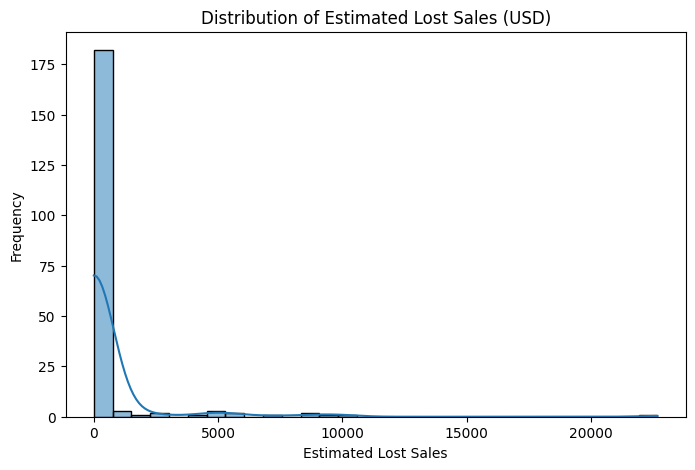

In [4]:
# Distribution of lost sales
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df["estimated_lost_sales"], bins=30, kde=True)
plt.title("Distribution of Estimated Lost Sales (USD)")
plt.xlabel("Estimated Lost Sales")
plt.ylabel("Frequency")
plt.show()

### 4.3.2 Interpretation. Distribution of Estimated Lost Sales.

**a) Revenue leakage is highly concentrated.**

The distribution of `estimated_lost_sales` is strongly right-skewed.  
Most products generate little or no lost revenue, while a relatively small subset of SKUs produces disproportionately large losses.

**b) Hidden inventory can generate substantial financial impact.**

When isolating products with hidden inventory (`unexhibited_units > 0`), the **average estimated lost sales per affected SKU reaches approximately $4,531**, indicating that backroom storage can translate into meaningful revenue leakage.

**c) Premium products drive a large share of losses.**

Higher-priced items that remain unexhibited contribute disproportionately to total lost revenue, suggesting that visibility constraints are particularly costly for premium merchandise.

**d) Operational implication.**

Revenue leakage is **not evenly distributed across the assortment**.  
Targeted improvements in shelf visibility for high-value SKUs can recover a meaningful portion of unrealized sales without requiring changes to overall inventory levels.

In [5]:
# Average lost sales among SKUs with hidden inventory

affected_skus = df[df["unexhibited_units"] > 0]

avg_loss_affected = affected_skus["estimated_lost_sales"].mean()

print(f"Average lost sales among affected SKUs: ${avg_loss_affected:,.2f}")

Average lost sales among affected SKUs: $4,531.39


In [6]:
# Percentage of SKUs affected by hidden inventory
affected_rate = (df["unexhibited_units"] > 0).mean()

print(f"Share of SKUs with hidden inventory: {affected_rate:.1%}")

Share of SKUs with hidden inventory: 12.0%


### 4.3.3 Correlation Matrix.

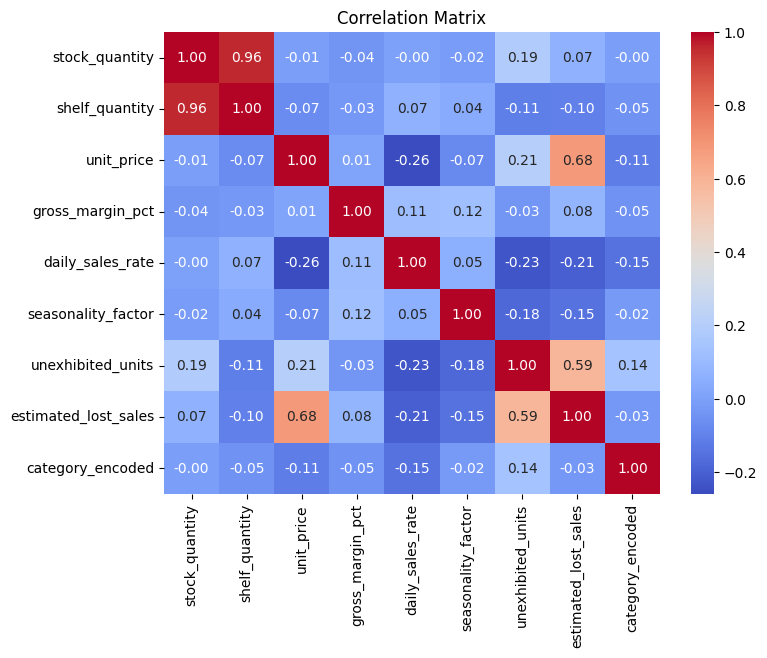

In [7]:

# Correlation matrix

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### 4.3.4 Interpretation. Correlation Matrix.

**a) Product value is strongly associated with potential revenue leakage.**

`unit_price` shows a strong positive correlation with `estimated_lost_sales` (0.68).  
Higher-priced products generate disproportionately larger revenue losses when they remain unexhibited.

**b) Hidden inventory is a primary driver of lost sales.**

`unexhibited_units` exhibits a strong positive relationship with lost sales (0.59), indicating that products stored in backroom areas rather than displayed on shelves are a major contributor to unrealized revenue.

**c) Faster-moving products are less likely to generate lost revenue.**

`daily_sales_rate` shows a mild negative correlation with lost sales (-0.21), suggesting that high-turnover items are typically prioritized for shelf display and therefore less affected by hidden inventory.

**d) Shelf capacity is closely tied to total inventory levels.**

`stock_quantity` and `shelf_quantity` exhibit a very strong correlation (0.96), reflecting the operational relationship between total inventory and available display capacity.

**e) Operational Implication.**

The correlation structure reinforces the central operational insight of the analysis:  
**revenue leakage is primarily driven by the interaction between product value and hidden inventory levels.**

Products that are both **high-value and stored in backroom inventory** represent the greatest opportunity for revenue recovery through improved shelf visibility.

### 4.3.5 Pairplot Relationships.

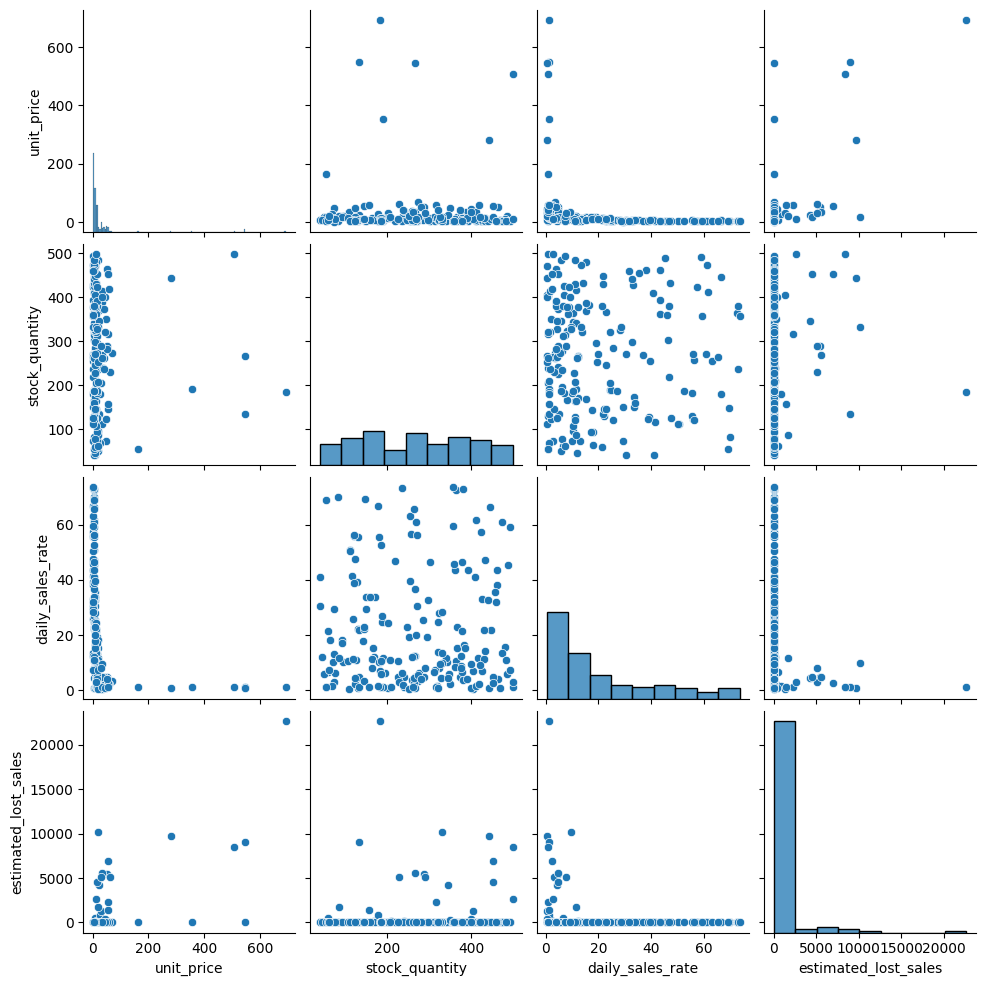

In [8]:
# Pairplot relationships

sns.pairplot(df[["unit_price","stock_quantity","daily_sales_rate","estimated_lost_sales"]])
plt.show()

### 4.3.6 Interpretation. Pairplot Relationships.

**a) Product value differentiates the highest revenue losses.**

The pairplot confirms that products with higher `unit_price` values are disproportionately associated with larger `estimated_lost_sales`.  
High-value items therefore represent the most financially sensitive category when inventory remains unexhibited.

**b) Revenue leakage is concentrated in a limited subset of SKUs.**

Most observations cluster near zero lost sales, while a small group of products produces substantially larger losses.  
This visual pattern reinforces the strong right-skew observed in the distribution of estimated lost sales.

**c) Inventory volume alone does not explain lost revenue.**

Variation in `stock_quantity` does not show a clear relationship with lost sales, suggesting that total inventory levels are not the primary driver of revenue leakage.

**d) Fast-moving products are typically protected from hidden inventory.**

Products with higher `daily_sales_rate` values cluster near zero lost sales, reflecting the operational reality that high-turnover items are usually prioritized for shelf display.

**e) Operational Implication.**

The pairplot reinforces a consistent pattern across the analysis:  
**lost revenue emerges primarily when high-value products remain stored in backroom inventory rather than displayed to customers.**

Improving shelf visibility for premium items represents the most direct operational lever for reducing unrealized sales.

### 4.4 Predictive Modeling Using OLS Regression.

To quantify the drivers of lost sales, the analysis applies an **Ordinary Least Squares (OLS)** regression model.

The model uses selected operational predictors that represent key store-level and product-level characteristics:

- `unit_price`
- `stock_quantity`
- `daily_sales_rate`
- `category_encoded`

The dataset is divided into training and testing subsets to evaluate predictive performance on unseen data. OLS is used as an interpretable baseline model, allowing us to estimate how operational product characteristics influence the magnitude of lost revenue when products remain unexhibited.

Although more complex models could capture nonlinear patterns, OLS provides a transparent starting point for understanding the main drivers of revenue leakage.

In [9]:
# Define predictors and target
X = df[[
    "unit_price",
    "daily_sales_rate",
    "stock_quantity",
    "category_encoded"
]]

y = df["estimated_lost_sales"]

# Train / Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Log transform target to stabilize skew
import numpy as np
y_train_log = np.log1p(y_train)

# Add constant for OLS
import statsmodels.api as sm
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Fit model
model = sm.OLS(y_train_log, X_train_const).fit()

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     estimated_lost_sales   R-squared:                       0.303
Model:                              OLS   Adj. R-squared:                  0.285
Method:                   Least Squares   F-statistic:                     16.85
Date:                  Mon, 27 Apr 2026   Prob (F-statistic):           1.73e-11
Time:                          18:46:03   Log-Likelihood:                -349.65
No. Observations:                   160   AIC:                             709.3
Df Residuals:                       155   BIC:                             724.7
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               

In [10]:
# Predict log values
y_pred_log = model.predict(X_test_const)

# Convert predictions back to original scale
y_pred = np.expm1(y_pred_log)

# Preview predictions
pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
}).head(10)

,Actual,Predicted
95,0.000000,8.555067
15,0.000000,1.247852
30,9673.809529,179.977300
158,0.000000,2.142010
128,0.000000,4.339527
115,0.000000,3.425813
69,0.000000,-0.068781
170,0.000000,0.714212
174,0.000000,0.507842
45,0.000000,-0.114305


### 4.4.1 Model Results and Key Drivers of Revenue Leakage.

The OLS regression model quantifies how operational product characteristics influence the magnitude of estimated lost sales.

a) Model Performance.

- **R² = 0.30**

**The model explains approximately 30% of the variability in estimated lost sales.**

While not capturing the full complexity of retail dynamics, the model identifies statistically meaningful relationships between product characteristics and revenue leakage.

b) **Model significance.**

The overall regression is statistically significant **(F-statistic p < 0.001)**, indicating that the predictors collectively provide explanatory power.

c) Key Driver Identified.

- **Unit price is statistically significant (p < 0.001)**

The model indicates that **higher-value products are associated with greater lost sales when inventory remains unexhibited**.

This relationship is consistent with the operational logic observed during store testing: when expensive items remain in backroom storage rather than on shelves, each missed sale carries a larger financial impact.

d) Secondary Relationships.

- **Daily sales rate is negatively associated with lost sales (p = 0.010).**

Products with higher sales velocity tend to generate **lower lost sales**, reflecting the operational reality that fast-moving items are typically prioritized for shelf display.

e) **Stock quantity and product category.**

These variables do not appear statistically significant **at conventional confidence levels**, suggesting that inventory volume alone does not explain revenue leakage.

f) Operational Implication.

The regression results reinforce a central operational insight:

**Revenue leakage is primarily driven by the combination of product value and hidden inventory, rather than by overall inventory levels.**

Ensuring that high-value products remain visible and available on shelves can therefore drive a disproportionately large impact on store revenue performance.

### 4.5 Model Evaluation and Operational Interpretation.

Model performance is evaluated using two key regression metrics:

- **R² (Coefficient of Determination).** Measures the proportion of variance in lost sales explained by the model.
- **Root Mean Squared Error (RMSE).** Measures the magnitude of prediction error in dollar terms.

These metrics help assess whether the model provides a reliable approximation of revenue leakage patterns across SKUs.

To translate model performance into operational insight, predicted and actual lost sales are compared at the SKU level. This comparison allows us to:

- Evaluate prediction accuracy.  
- identify high-risk SKUs where hidden inventory may generate significant revenue leakage.  
- Highlight cases where the model over- or under-estimates losses.  

**IMPORTANT NOTE:** This finding aligns with the operational testing conducted during the pilot phase, where a small number of high-value categories concentrated the majority of hidden-inventory losses.

## 5. Key Results.

**Hidden backroom inventory creates measurable revenue leakage concentrated in a small set of high-value products.**

### 5.1 Material revenue loss per affected product.
**$4,531 average lost sales per affected SKU.**

When products remain stored in backroom inventory instead of being displayed, a significant portion of potential demand is never realized.  
The model estimates that each affected SKU generates approximately **$4.5K in unrealized revenue**, highlighting the financial sensitivity of shelf visibility.

### 5.2 Revenue leakage affects a targeted subset of the assortment.
**12% of SKUs contain hidden inventory.**

The problem is not evenly distributed across the product portfolio.  
Instead, lost sales originate from **a relatively small subset of SKUs**, indicating that operational bottlenecks rather than weak demand explain the majority of the leakage.

### 5.3 Higher-priced products drive the largest losses.
**Product price is the strongest statistical driver of lost sales.**

Regression results show that **higher-value products experience disproportionately larger revenue leakage when they remain unexhibited**.  
Because premium items generate higher revenue per unit, visibility failures translate directly into amplified financial impact.

### 5.4 Revenue leakage is highly concentrated.
A **small group of high-value SKUs with hidden inventory accounts for most of the estimated lost revenue**.

This concentration suggests that targeted operational interventions, such as improved shelf allocation or replenishment processes, could recover a meaningful portion of the unrealized sales.

## 6. Operational Implications

The analysis indicates that revenue leakage from unexhibited inventory is primarily an operational execution issue rather than a demand limitation. Improving shelf visibility and monitoring backroom inventory can therefore increase realized sales without increasing stock levels.

### 6.1 Operational Validation from Real Store Testing.

The skewed distribution observed in the simulated dataset is consistent with patterns identified during the original operational analysis conducted in retail stores.

**The validation of this initiative followed a structured operational testing approach, progressing from controlled single-store validation to multi-store pilot implementation.**


### a) Proof of Concept.

The initiative began with a **proof of concept in a single store** as part of a controlled validation phase.  
The objective was to verify whether hidden inventory could generate measurable revenue leakage when products remained in **backroom storage instead of being displayed on shelves**.

The initial test confirmed that **unexhibited inventory was directly associated with lost sales opportunities**.


### b) Pilot Program.

Following successful validation, the initiative progressed to a **pilot program involving eight stores** to assess consistency across operational environments.

The pilot tested whether the phenomenon observed in the first store was consistent across different geographic markets and operational environments.

The results revealed a consistent pattern:

- A **small number of categories concentrated the majority of revenue leakage**, typically higher-value or controlled-storage items.
- Several additional categories showed a **moderate probability of remaining unexhibited**, generating smaller but still measurable losses.


### 6.2 Operational KPI Implementation.

Based on these findings, the project team designed a **Key Performance Indicator (KPI)** to monitor the presence of unexhibited inventory at the store level.

The KPI was integrated into the company's **continuous improvement cycle** and standardized across stores to ensure consistent operational monitoring.

The indicator enabled store managers and regional operations teams to:

- Monitor compliance with product exhibition practices.  
- Identify categories with persistent backroom storage issues.  
- Quantify the financial impact of improved shelf visibility.  

This operational framework allowed the organization to **systematically reduce revenue leakage associated with hidden inventory while maintaining consistent merchandising standards across stores**.

### 6.3 Prioritize shelf visibility for high-value products.

   Higher-priced SKUs generate the largest financial losses when they remain stored in backroom inventory rather than displayed on shelves. Ensuring consistent shelf presence for premium products allows stores to capture demand that would otherwise remain unrealized.

### 6.4 Treat hidden backroom inventory as an operational warning signal.

   Persistent backroom storage should be interpreted as an indicator of operational execution problems such as shelf capacity constraints, delayed replenishment, or inconsistent merchandising practices.

### 6.5 Focus operational monitoring on high-risk product segments.

   Revenue leakage is concentrated in a relatively small subset of the assortment. Targeted monitoring of these higher-risk categories allows operational teams to address the majority of potential losses without increasing complexity across the full portfolio.

### 6.6 Integrate visibility metrics into store performance management.

   Introducing a KPI that tracks unexhibited inventory enables store managers to systematically monitor merchandising execution and identify opportunities to recover unrealized sales.

   

## 7. Business Value.

The analysis quantifies a measurable source of unrealized revenue linked to product visibility failures inside stores. Hidden inventory in backroom areas prevents available stock from converting into actual sales, creating revenue leakage that remains largely invisible in traditional performance metrics.

### 7.1 Revenue recovery without additional inventory investment.

Improving shelf visibility converts existing inventory into realized sales. The financial impact comes from better merchandising execution rather than higher purchasing volumes or additional stock.

### 7.2 Targeted operational focus.

Revenue leakage is concentrated in a relatively small subset of higher-value products. A limited number of SKUs account for a disproportionate share of unrealized revenue, making focused operational monitoring more effective than broad inventory controls.

### 7.3 Measurable merchandising performance.

Unexhibited inventory can be translated into a measurable operational indicator. Tracking this metric enables consistent monitoring of product visibility and highlights locations where merchandising execution affects store revenue.

<h3>7.4 Business Value Summary.</h3>

<table>
  <thead>
    <tr>
      <th align="left">Key Indicator</th>
      <th align="left">Result</th>
      <th align="left">Business Interpretation</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Average Lost Sales per Affected Product</td>
      <td>$4,531 MXN (≈ $267 USD)</td>
      <td>Hidden inventory suppresses a measurable portion of potential revenue per SKU.</td>
    </tr>
    <tr>
      <td>Estimated Network Impact (13,000 stores)*</td>
      <td>$58.9M MXN (≈ $3.5M USD)</td>
      <td>Even unit-level revenue leakage scales into a multi-million-dollar recovery opportunity across a large retail network.</td>
    </tr>
    <tr>
      <td>SKUs with Hidden Inventory</td>
      <td>12% of assortment</td>
      <td>Revenue leakage is concentrated in a limited subset of products rather than across the full portfolio.</td>
    </tr>
    <tr>
      <td>Primary Driver of Lost Sales</td>
      <td>Product Price</td>
      <td>Higher-value products experience disproportionately larger revenue losses when they remain unexhibited.</td>
    </tr>
    <tr>
      <td>Concept Implementation</td>
      <td>1 store (initial validation)</td>
      <td>The analytical insight was first tested in a controlled operational environment.</td>
    </tr>
    <tr>
      <td>Pilot Implementation</td>
      <td>One region (multi-store pilot)</td>
      <td>The initiative demonstrated consistent scalability across multiple locations.</td>
    </tr>
    <tr>
      <td>KPI Implementation</td>
      <td>Inventory Visibility KPI introduced</td>
      <td>Store management gained a measurable indicator to monitor merchandising execution and prevent hidden inventory.</td>
    </tr>
  </tbody>
</table>

<p><small><small><span style="font-size:9px; line-height:1.1; color:#777;">
<em>*Note: Network extrapolation assumes baseline hidden inventory presence per store based on assortment-level impact. It is a directional estimate, not an exact total.</em>
</span></small></small></p>

## 8. Data Disclaimer.

The dataset used in this project was synthetically generated to simulate retail operational conditions and does not contain any proprietary or confidential company data.

The analytical scenario and operational context are inspired by real business challenges related to inventory visibility and merchandising execution in large retail networks. However, all numerical values, product records, and store-level observations presented in this notebook are simulated for analytical demonstration purposes.

This approach allows the analytical methodology, modeling techniques, and business interpretation to be demonstrated without exposing sensitive operational information.

**No proprietary or confidential company data is included in this project.**